In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy
import Corrfunc

from scipy.optimize import curve_fit
from Corrfunc.theory import xi

In [3]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [4]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [5]:

odir = "../../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [9]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [10]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [135]:
def cf_lin_w_bias(r, bias=1,R=None):
    bias_factor=bias**2
    cf = bias_factor*cf_lin(r)
    return cf

def cf_nl_w_bias(r, bias=1, R=None):
    bias_factor=bias**2
    cf = bias_factor*cf_nl(r)
    return cf

def lognormal_cf(xi_c, sigma, R,bias=1, rmax=3, dr=0.1):
    #dr = 0.00003
    Nr = int( rmax / dr )
  
    r_list = np.array([ dr * (i+1) for i in range(Nr) ])
    
    d = 2*R
    x = np.log10(r_list / d) / (np.sqrt(2) * sigma)
    fr = 1 - 0.5 * (1.0 + scipy.special.erf(x))
    if sigma == 0:
        xi_d = xi_c(r_list,bias=bias)
    else:
        xi_d = (1 - fr) * (xi_c(r_list, bias=bias) + 1) - 1

    return r_list, xi_d

def pk_from_cf(logks):
    rmax = 100
    dr=0.01
    #r_list = np.arange(1e-4,rmax,dr)
    r_list, cf = lognormal_cf(cf_nl_w_bias, sigma=0.17, R=0.37, bias=2, rmax=rmax, dr=dr)
    #r_list, cf = lognormal_cf(cf_nl_w_bias, sigma=0.175, R=0.38, bias=2, rmax=rmax, dr=dr)
    
    k_list = 10**np.array(logks)
    Pk = np.zeros(len(k_list))
    prefactor = dr * 4. * np.pi
    for i, k in enumerate(k_list):
        sin_term = np.sin(k * r_list) / (k * r_list)
        Pk[i] = np.sum(prefactor * r_list**2 * sin_term * cf)


    return Pk

In [15]:
tng_dir = "/cosma7/data/dp004/dc-zhan5/TNG/snap40/SubhaloFlag_all/mvir/ihalo"
tng_data = np.loadtxt(f"{tng_dir}/sfr-halomass_sum.txt")
mhalo_tng = tng_data[:,1]
pos_tng = tng_data[:,2:5]
sfr_tng = tng_data[:,5]

mask = mhalo_tng > 10
mhalo_tng = mhalo_tng[mask]
pos_tng = pos_tng[mask]
sfr_tng = sfr_tng[mask]

In [19]:
rmin = 0.01
rmax = 3
nbins = 100
boxsize=205
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1)
results_weighted = xi(boxsize, 2, rbins , pos_tng[:,0],pos_tng[:,1],pos_tng[:,2], 
             weights=10**sfr_tng,weight_type='pair_product',output_ravg=True)

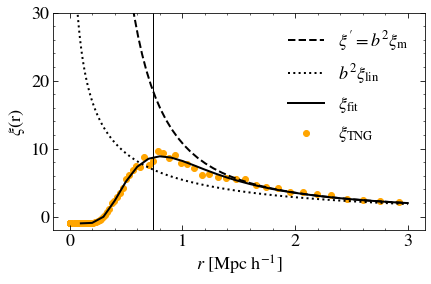

In [145]:
plt.vlines(0.37*2, ymin=-2, ymax=30, color="k", linewidth=1)
#plt.scatter(results["ravg"], results["xi"], label="TNG all")
plt.scatter(results_weighted["ravg"], results_weighted["xi"], label=r"$\xi_{\mathrm{TNG}}$", c="orange")

# plt.plot(rbins, cf_lin_excl(rbins, R=0.3), label="linear w exclusion")
plt.plot(rbins, cf_nl_w_bias(rbins, bias=2), linestyle="dashed", c="k", label=r"$\xi'= b^2 \xi_{\mathrm{m}}$")

#plt.plot(rbins, cf_nl_excl(rbins, bias=2, R=0.3), linestyle="dashed", c="grey", label="Halofit w exclusion")

#plt.plot(rbins, cf_lin_excl(rbins, bias=2, R=0.3), linestyle="dotted", c="grey", label="Linear w exclusion")
plt.plot(rbins, cf_lin_w_bias(rbins, bias=2), linestyle="dotted", c="k", label=r"$b^2 \xi_{\mathrm{lin}}$")

r_list, cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.17, R=0.37)
#r_list, cf_nl01 = lognormal_cf(cf_nl_w_bias, bias=2, sigma=0.18, R=0.38)
plt.plot(r_list, cf_nl01, label=r"$\xi_{\mathrm{fit}}$", c="k")
#plt.scatter(np.log10(results["ravg"]), np.log10(results["xi"]))
plt.xlabel("$r$ [Mpc h$^{-1}$]")
plt.ylabel(r"$\xi$(r)")
plt.legend()
#plt.xscale("log")
plt.ylim(-2,30)
#plt.savefig("../../figures/cf_fit.pdf", format="pdf", bbox_inches="tight")

In [136]:
ks_tng = Pk_sum10["k"]
logks_tng = np.log10(ks_tng)

halo2 = Pk_sum10["power"].real-Pk_sum10.attrs["shotnoise"]
halofit = Pnl(10**logks_tng)
linear = Plin(10**logks_tng)
total = Pk_gal10["power"].real
pk_fit = pk_from_cf(logks_tng)

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


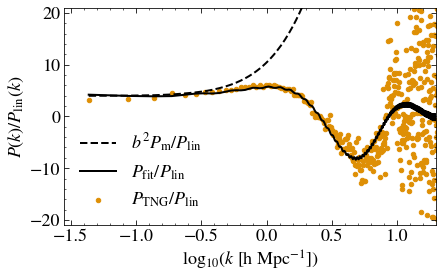

In [152]:
plt.plot(logks_tng, 4*halofit/linear, label="$b^2 P_{\mathrm{m}}/P_{\mathrm{lin}}$",linestyle="dashed", c="k" )
plt.scatter((logks_tng), (halo2/linear), label="$P_{\mathrm{TNG}}/P_{\mathrm{lin}}$", c=palette_tab10[1],s=20)
plt.plot(logks_tng, pk_fit/linear, label="$P_{\mathrm{fit}}/P_{\mathrm{lin}}$", c="k")
plt.ylim(-21,21)
plt.xlim(-1.55,1.3)
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")
plt.ylabel("$P(k)/P_{\mathrm{lin}}(k)$")
plt.legend()
#plt.savefig("../../figures/bias_lin_fit.pdf", format="pdf", bbox_inches="tight")

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


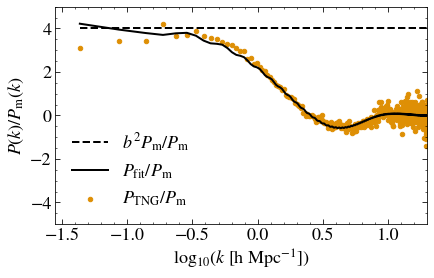

In [153]:
plt.plot(logks_tng, 4*halofit/halofit, label="$b^2 P_{\mathrm{m}}/P_{\mathrm{m}}$", linestyle="dashed", c="k")
plt.scatter(logks_tng, halo2/halofit, label="$P_{\mathrm{TNG}}/P_{\mathrm{m}}$", c=palette_tab10[1],s=20)
plt.plot(logks_tng, pk_fit/halofit, label="$P_{\mathrm{fit}}/P_{\mathrm{m}}$", c="k")
plt.ylim(-5,5)
plt.xlim(-1.55,1.3)
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")
plt.ylabel("$P(k)/P_{\mathrm{m}}(k)$")
plt.legend()
#plt.savefig("../../figures/bias_nl_fit.pdf", format="pdf", bbox_inches="tight")